# Copernicus Climate Data Store (CDS) access using xcube

This notebook walks provides a walk-through demonstrating how to use xcube and the xcube Climate Data Store (CDS) plugin to read and explore [drought indices data from the CDS](https://cds.climate.copernicus.eu/datasets/derived-drought-historical-monthly?tab=overview).

Before using this notebook, ensure that you have set up xcube, the CDS plugin, and Jupyter Lab as described in the [Ex0-CDS-store-Setup](./Ex0-CDS-store-setup.ipynb) notebook.

First, we import some necessary libraries.

In [1]:
# xcube imports
import xcube
from xcube.core.store import new_data_store

# Various utilities
import shapely.geometry
import IPython.display

# For the orthographic map projection
import matplotlib as mpl
import matplotlib.pyplot as plt

Configure matplotlib to display graphs inline directly in the notebook and set a sensible default figure size.

Create a CDS data store object. The optional `normalize_names` parameter specifies that variable names in returned data cubes will be converted to legal Python identifiers, if required.

In [2]:
cds_store = new_data_store("cds", normalize_names=True)

Find out which datasets are available from this store. We get a list of tuples; the first member of each tuple is the data ID, and the second member is a short description of the dataset. We pick `"derived-drought-historical-monthly:reanalysis"`.

In [3]:
data_ids = list(cds_store.get_data_ids())
data_ids

['reanalysis-era5-single-levels:ensemble_mean',
 'reanalysis-era5-single-levels:ensemble_members',
 'reanalysis-era5-single-levels:ensemble_spread',
 'reanalysis-era5-single-levels:reanalysis',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_ensemble_members',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-land-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-land',
 'satellite-soil-moisture:saturation:daily',
 'satellite-soil-moisture:saturation:10-day',
 'satellite-soil-moisture:saturation:monthly',
 'satellite-soil-moisture:volumetric:daily',
 'satellite-soil-moisture:volumetric:10-day',
 'satellite-soil-moisture:volumetric:monthly',
 'satellite-sea-ice-thickness:envisat',
 'satellite-sea-ice-thickness:cryosat-2',
 'derived-drought-historical-monthly:reanalysis']

In [4]:
data_id = (
    "derived-drought-historical-monthly:reanalysis"
)

Let's see what parameters we can specify when opening the dataset. Four are listed as required parameters: `time_range`, `bbox`, `accumulation_period` and `variable_names`. The enumeration in `properties → variable_names → items` lists the 5 variables we can request. 

In [5]:
cds_store.get_open_data_params_schema(data_id)

We can request any number of variables, but for this example we will look at `standardised_precipitation_index` and its two quaily datasets.

In [6]:
variable_names = [
    "standardised_precipitation_index",
    "probability_of_zero_precipitation_spi",
    "test_for_normality_spi",
]

Next we can request multiple accumulation periods.

In [7]:
accumulation_periods = [1, 3, 6]

Define the bounding box for the area of interest. For this example, we will be using the mid-latitudes of Europe.

In [8]:
w = -15  # degree
s = 35  # degree
e = 40  # degree
n = 75  # degree

bbox = [w, s, e, n]

Plot the bounding box on a map to check that we have the correct area.

In [9]:
IPython.display.GeoJSON(shapely.geometry.box(*bbox).__geo_interface__)

<IPython.display.GeoJSON object>

For the time range, we select the years 2020 to 2023. The dates are specified in ISO-8601 format.

In [10]:
time_range = ["2020-01-01", "2023-12-31"]

Open the data cube from the store. It may take one or two minutes for the CDS servers to process the request.

In [11]:
cube = cds_store.open_data(
    data_id,
    variable_names=variable_names,
    accumulation_periods=accumulation_periods,
    bbox=bbox,
    time_range=time_range,
)

xcube-cds version 1.1.1.dev0
2025-11-27 17:17:06,213 WARNING [2025-10-30T00:00:00] Downloading data from this dataset requires that the user be registered with the CDS. The use of the API requires a CDS API key.
2025-11-27 17:17:06,214 INFO Request ID is 9abb961c-c7db-401a-94cd-ec965091746a
2025-11-27 17:17:06,292 INFO status has been updated to accepted
2025-11-27 17:17:11,305 INFO status has been updated to running
2025-11-27 17:17:14,762 INFO status has been updated to successful


a101787821ccdf4ae64fa1a62504f257.zip:   0%|          | 0.00/61.6M [00:00<?, ?B/s]

Show a summary of the dataset in the notebook.

In [12]:
cube

<xarray.Dataset> Size: 120MB
Dimensions:            (time: 48, lat: 159, lon: 219)
Coordinates:
  * time               (time) datetime64[ns] 384B 2020-01-01T06:00:00 ... 202...
  * lat                (lat) float64 1kB 74.75 74.5 74.25 ... 35.75 35.5 35.25
  * lon                (lon) float64 2kB -14.75 -14.5 -14.25 ... 39.5 39.75
Data variables:
    spi1               (time, lat, lon) float64 13MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spi3               (time, lat, lon) float64 13MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spi6               (time, lat, lon) float64 13MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spi1_pzero         (time, lat, lon) float64 13MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spi3_pzero         (time, lat, lon) float64 13MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spi6_pzero         (time, lat, lon) float64 13MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spi1_significance  (time, lat, lon) float64 13MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spi3_significance  (time, lat, lon) float64 13MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
    spi6_significance  (time, lat, lon) float64 13MB dask.array<chunksize=(1, 159, 219), meta=np.ndarray>
Attributes: (12/14)
    Conventions:         CF-1.8
    institution:         European Centre for Medium-Range Weather Forecasts
    source:              DRYFALL v1.0
    license:             Creative Commons Attribution v4
    citation_statement:  Drought indicators derived from ERA5 reanalysis
    data_srs:            EPSG:4326
    ...                  ...
    climate_start_date:  1991-01-01
    climate_end_date:    2020-12-31
    frequency:           Monthly
    contact_person:      support@ecmwf.int
    CDI:                 Climate Data Interface version 1.9.10 (https://mpime...
    CDO:                 Climate Data Operators version 1.9.10 (https://mpime...

We can plot a time slice and a timeseries as an example:

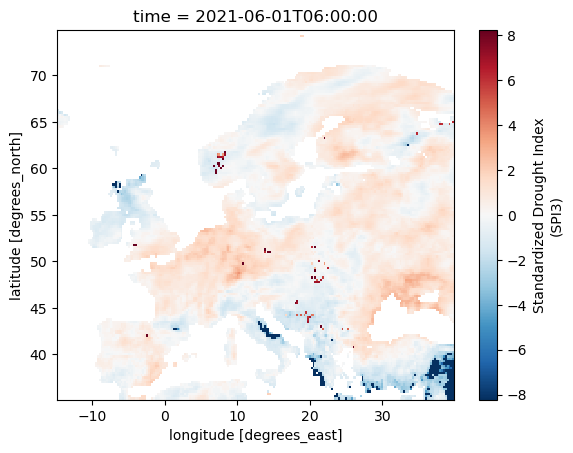

In [13]:
time_slice = cube.spi3.sel(time="2021-06-01 00:00:00", method="nearest")
time_slice.plot()

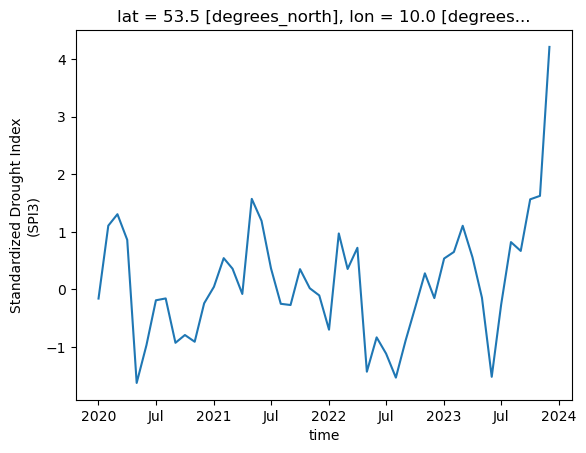

In [14]:
time_series = cube.spi3.sel(lat=53.5, lon=10., method="nearest")
time_series.plot()